# Deep Learning, DL Models and Applications
## Skill Development Tasks (1-15)

### Implementations:
- Neural Networks from Scratch
- Optimization Algorithms
- CNN Architectures
- Sequence Models
- Generative Models
- Transformers
- Distributed Training

### Frameworks:
- NumPy
- PyTorch
- TorchVision
- Matplotlib
- SciPy
- Scikit-Learn

Nandana R Nair

In [13]:
# Install Required Libraries
!pip install einops albumentations torchinfo

In [14]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [15]:
# ==========================================================
# TASK 12
# Convolutional Autoencoder for Anomaly Detection
# ==========================================================

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from skimage.metrics import structural_similarity as ssim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [16]:


# ==========================================================
# Hyperparameters
# ==========================================================

BATCH_SIZE = 64

LATENT_DIM = 128

EPOCHS = 5

LR = 0.001

In [17]:


# ==========================================================
# Dataset
# Using CIFAR10 as a demo
# Only Airplane images are treated as "Normal"
# ==========================================================

transform = transforms.Compose([
    transforms.ToTensor()
])

trainset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

testset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

NORMAL_CLASS = 0

train_images = []

for img, label in trainset:
    if label == NORMAL_CLASS:
        train_images.append(img)

train_loader = torch.utils.data.DataLoader(
    train_images,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    testset,
    batch_size=1,
    shuffle=True
)

print("Normal Training Images:", len(train_images))

Normal Training Images: 5000


In [18]:


# ==========================================================
# Convolutional Autoencoder
# ==========================================================

class AutoEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64,LATENT_DIM,3,padding=1),

            nn.ReLU()

        )

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(LATENT_DIM,64,2,stride=2),

            nn.ReLU(),

            nn.ConvTranspose2d(64,32,2,stride=2),

            nn.ReLU(),

            nn.Conv2d(32,3,3,padding=1),

            nn.Sigmoid()

        )

    def forward(self,x):

        latent = self.encoder(x)

        reconstructed = self.decoder(latent)

        return reconstructed

In [19]:


# ==========================================================
# Model
# ==========================================================

model = AutoEncoder().to(device)

optimizer = optim.Adam(model.parameters(), lr=LR)

criterion = nn.MSELoss()

In [20]:


# ==========================================================
# SSIM Loss
# ==========================================================

def ssim_loss(original, reconstructed):

    original = original.detach().cpu().numpy()

    reconstructed = reconstructed.detach().cpu().numpy()

    score = 0

    for i in range(original.shape[0]):

        score += ssim(
            np.transpose(original[i], (1,2,0)),
            np.transpose(reconstructed[i], (1,2,0)),
            channel_axis=2,
            data_range=1.0
        )

    score /= original.shape[0]

    return 1-score

In [21]:


# ==========================================================
# Training
# ==========================================================

print("\nTraining...\n")

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for images in train_loader:

        images = images.to(device)

        outputs = model(images)

        mse = criterion(outputs, images)

        ssim_component = ssim_loss(images, outputs)

        loss = mse + 0.2 * ssim_component

        optimizer.zero_grad()

        mse.backward()

        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss : {total_loss/len(train_loader):.4f}")

print("\nTraining Completed!")


Training...

Epoch 1 Loss : 0.1614
Epoch 2 Loss : 0.0987
Epoch 3 Loss : 0.0763
Epoch 4 Loss : 0.0618
Epoch 5 Loss : 0.0547

Training Completed!


In [22]:


# ==========================================================
# Test One Image
# ==========================================================

model.eval()

image, label = next(iter(test_loader))

image = image.to(device)

with torch.no_grad():

    reconstructed = model(image)

In [23]:


# ==========================================================
# Reconstruction Error
# ==========================================================

error = torch.abs(image - reconstructed)

error_map = error.squeeze().mean(0).cpu().numpy()


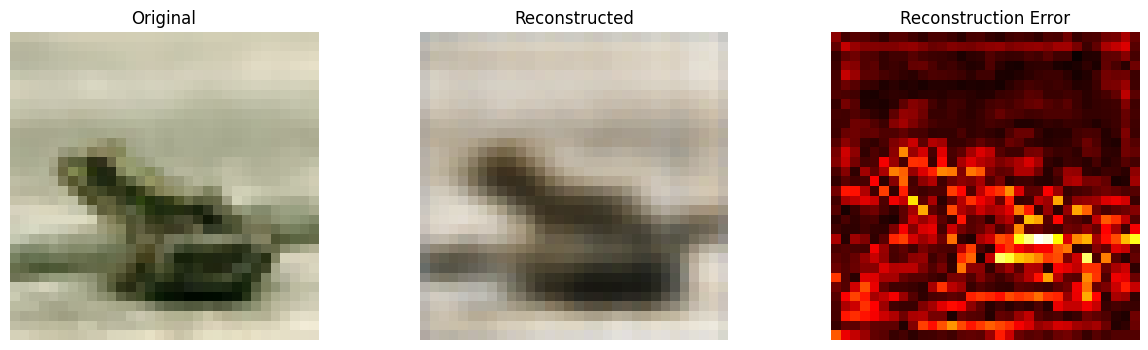

Actual Label: 6
Task 12 Completed Successfully!


In [24]:

# ==========================================================
# Display
# ==========================================================

plt.figure(figsize=(15,4))

plt.subplot(1,3,1)

plt.imshow(image.squeeze().permute(1,2,0).cpu())

plt.title("Original")

plt.axis("off")

plt.subplot(1,3,2)

plt.imshow(reconstructed.squeeze().permute(1,2,0).cpu())

plt.title("Reconstructed")

plt.axis("off")

plt.subplot(1,3,3)

plt.imshow(error_map,cmap="hot")

plt.title("Reconstruction Error")

plt.axis("off")

plt.show()

print("Actual Label:",label.item())

print("Task 12 Completed Successfully!")